In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Dataset

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()# Load Dataset

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url)

df.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [3]:
# Dataset Info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31962 entries, 0 to 31961
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      31962 non-null  int64 
 1   label   31962 non-null  int64 
 2   tweet   31962 non-null  object
dtypes: int64(2), object(1)
memory usage: 749.2+ KB


In [4]:
# Select Important Columns

df = df[['label', 'tweet']]

df.head()

,label,tweet
0,0,@user when a father is dysfunctional and is s...
1,0,@user @user thanks for #lyft credit i can't us...
2,0,bihday your majesty
3,0,#model i love u take with u all the time in ...
4,0,factsguide: society now #motivation


In [5]:
# Clean Text Function

def clean_text(text):

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'#', '', text)

    text = re.sub(r'[^A-Za-z\s]', '', text)

    text = text.lower()

    return text

In [6]:
# Apply Cleaning

df['clean_tweet'] = df['tweet'].apply(clean_text)

df.head()

,label,tweet,clean_tweet
0,0,@user when a father is dysfunctional and is s...,when a father is dysfunctional and is so sel...
1,0,@user @user thanks for #lyft credit i can't us...,thanks for lyft credit i cant use cause they...
2,0,bihday your majesty,bihday your majesty
3,0,#model i love u take with u all the time in ...,model i love u take with u all the time in u...
4,0,factsguide: society now #motivation,factsguide society now motivation


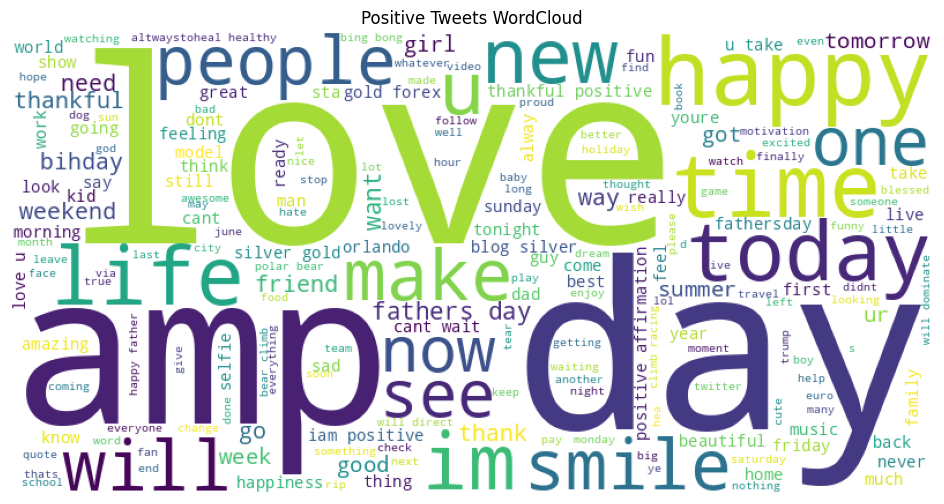

In [7]:
# Positive Tweets WordCloud

positive_text = " ".join(
    df[df['label']==0]['clean_tweet']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Tweets WordCloud")

plt.show()

In [10]:
# Features and Target

X = df['clean_tweet']

y = df['label']

In [11]:
# Vectorization

vectorizer = CountVectorizer()

X_vectorized = vectorizer.fit_transform(X)

In [12]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
# Logistic Regression Model

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [14]:
# Prediction

y_pred = model.predict(X_test)

In [15]:
# Accuracy Score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9596433599249179


In [16]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5937
           1       0.86      0.52      0.65       456

    accuracy                           0.96      6393
   macro avg       0.91      0.76      0.81      6393
weighted avg       0.96      0.96      0.96      6393



In [17]:
# Custom Prediction

sample = ["I love this beautiful world"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 0:
    print("Positive Sentiment 😊")
else:
    print("Negative Sentiment 😡")

Positive Sentiment 😊
